# INF2008 Group Project (Stage 1)
By: Group 25 Lab P2

This notebook documents Stage 1 of the INF2008 Group Machine Learning Project, following the CRISP-DM methodology. It covers the following phases:
1) Business Understanding
2) Data Understanding
3) Data Preparation
4) Baseline Modelling (default settings, cleaned dataset)
5) Feature Engineering
6) Baseline Modelling (on engineered dataset)
7) Evaluation

The task is a binary classification problem using the UCI Bank Marketing Dataset. [1] The focus of this stage is not on maximising model performance, but on establishing a sound analytical foundation by understanding the problem context, assessing data suitability, and validating feasibility through baseline models. Feature engineering is explored as an extension to assess whether additional economic context improves model performance.

In [705]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

### 1. Business Understanding

> **Note:** The business scenario below is a simulated context constructed for the purpose of the project, as per the project instructions.

Problem:
- A Portuguese bank conducts telemarketing campaigns for term deposit subscriptions, averaging 15,000 calls per year
- Average net revenue per subscription: $500
- Conversion rate: only 12% (88% rejection rate)
- This results in high operational waste and significant loss in potential revenue

Decision Context:
- Which clients should be prioritised for contact?

Success Metric:
- Conversion Rate (%)

Stakeholders:
- Marketing Managers, Bank Clients, Telemarketing Agents

Intervention:
- A machine learning model predicts the subscription probability of each client prior to contact
- Probabilities are ranked to focus the 15,000-call capacity on the highest-probability clients

Value:
- Increased conversion rate: 12% to 20% (+1,200 subscribers)
- Increased yearly revenue: $900,000 to $1,500,000 (+$600,000)

Potential Risks:
- Campaign Fatigue: Repeatedly targeting the same high-probability clients could lead to diminishing returns
- Missed Opportunities: Rarely contacting low-probability clients could mean missing emerging subscribers

### 2. Data Understanding

##### 2.1 Data Loading

In [706]:
df = pd.read_csv('data/raw/bank-additional-full.csv', delimiter=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


##### 2.2 Dataset Dimensions

In [707]:
df.shape

(41188, 21)

##### 2.3 Target Distribution

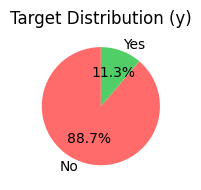

No:  36,548 (88.7%)
Yes: 4,640 (11.3%)


In [708]:
counts = df['y'].value_counts()
labels = ['No', 'Yes']
colors = ['#ff6b6b', '#51cf66']

fig, ax = plt.subplots(figsize=(2, 2))
ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Target Distribution (y)')
plt.tight_layout()
plt.show()

print(f"No:  {counts['no']:,} ({counts['no']/len(df)*100:.1f}%)")
print(f"Yes: {counts['yes']:,} ({counts['yes']/len(df)*100:.1f}%)")

##### 2.4 Descriptive Statistics

In [709]:
df.describe(include='all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


##### 2.5 Semantic Table

In [710]:
semantic_table = pd.DataFrame([
    ('age',           "Client's age in years",                                                                                                                                          'feature', 'numerical discrete'),
    ('job',           'Type of job (admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)',              'feature', 'categorical nominal'),
    ('marital',       'Marital status (divorced, married, single, unknown)',                                                                                                            'feature', 'categorical nominal'),
    ('education',     'Level of education (basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown)',                                   'feature', 'categorical ordinal'),
    ('default',       'Has credit in default? (no, yes, unknown)',                                                                                                                      'feature', 'categorical nominal'),
    ('housing',       'Has housing loan? (no, yes, unknown)',                                                                                                                           'feature', 'categorical nominal'),
    ('loan',          'Has personal loan? (no, yes, unknown)',                                                                                                                          'feature', 'categorical nominal'),
    ('contact',       'Communication type (cellular, telephone)',                                                                                                                       'feature', 'categorical nominal'),
    ('month',         'Last contact month of year (mar, apr, may, jun, jul, aug, sep, oct, nov, dec)',                                                                                 'feature', 'categorical ordinal'),
    ('day_of_week',   'Last contact day of the week (mon, tue, wed, thu, fri)',                                                                                                        'feature', 'categorical ordinal'),
    ('duration',      'Last contact duration in seconds',                                                                                                                               'feature', 'numerical continuous'),
    ('campaign',      'Number of contacts during this campaign',                                                                                                                        'feature', 'numerical discrete'),
    ('pdays',         'Days since last contact from a previous campaign',                                                                                                               'feature', 'numerical discrete'),
    ('previous',      'Number of contacts before this campaign',                                                                                                                        'feature', 'numerical discrete'),
    ('poutcome',      'Outcome of the previous campaign (failure, nonexistent, success)',                                                                                               'feature', 'categorical nominal'),
    ('emp.var.rate',  'Quarterly % change in employment in Portugal (range: -3.4 to 1.4). Positive = job growth, negative = job losses. Values near 1.4 indicate strong employment',  'feature', 'numerical continuous'),
    ('cons.price.idx','Price level index for consumer goods in Portugal (range: 92.2 to 94.8). Higher values indicate higher cost of living',                                          'feature', 'numerical continuous'),
    ('cons.conf.idx', 'Survey-based consumer sentiment in Portugal (range: -50.8 to -26.9). All values are negative; less negative indicates more positive sentiment',                 'feature', 'numerical continuous'),
    ('euribor3m',     'Daily interbank lending rate (range: 0.634 to 5.045). Higher rate = better deposit returns, making term deposits more attractive to clients',                   'feature', 'numerical continuous'),
    ('nr.employed',   'Total employed persons in Portugal (thousands)',                                                                                                                  'feature', 'numerical continuous'),
    ('y',             'Subscribed to a term deposit? (yes, no)',                                                                                                                        'target',  'boolean'),
], columns=['column', 'description', 'role', 'data_type'])

semantic_table.style.hide(axis='index').set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

column,description,role,data_type
age,Client's age in years,feature,numerical discrete
job,"Type of job (admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)",feature,categorical nominal
marital,"Marital status (divorced, married, single, unknown)",feature,categorical nominal
education,"Level of education (basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown)",feature,categorical ordinal
default,"Has credit in default? (no, yes, unknown)",feature,categorical nominal
housing,"Has housing loan? (no, yes, unknown)",feature,categorical nominal
loan,"Has personal loan? (no, yes, unknown)",feature,categorical nominal
contact,"Communication type (cellular, telephone)",feature,categorical nominal
month,"Last contact month of year (mar, apr, may, jun, jul, aug, sep, oct, nov, dec)",feature,categorical ordinal
day_of_week,"Last contact day of the week (mon, tue, wed, thu, fri)",feature,categorical ordinal


##### 2.6 Duplicate and Missing Values

In [711]:
rows_with_unknown = (df == 'unknown').any(axis=1).sum()
counts = [df.isna().any(axis=1).sum(), df.duplicated().sum(), rows_with_unknown]

display(pd.DataFrame({
    'count': counts,
    '% of rows': [round(c / len(df) * 100, 2) for c in counts]
}, index=['rows with missing values', 'duplicate rows', 'rows with "unknown" values']))

unknown_counts = (df == 'unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
display(pd.DataFrame({
    '"unknown" count': unknown_counts,
    '% of rows': (unknown_counts / len(df) * 100).round(2)
}))

,count,% of rows
rows with missing values,0,0.00
duplicate rows,12,0.03
"rows with ""unknown"" values",10700,25.98


,"""unknown"" count",% of rows
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


##### 2.7 Feature Leakage and Dangerous Columns

- The `duration` column records the length of the last phone call in seconds. This is only known **after** the call ends and is highly correlated with the outcome (longer calls tend to result in a subscription). Including it in a predictive model would constitute data leakage, as it would not be available at prediction time (before the call is made).
- The `pdays` column uses 999 as a sentinel value, meaning the client was never previously contacted. This is not a real number of days and will distort any statistical analysis or model that treats it as a continuous value.

### 3. Data Preparation (Minimal only for Stage 1)

##### 3.1 Handling Missing Values

As identified in section 2.6, the dataset contains no explicit missing values (NaN). However, several columns contain `'unknown'` as a value, accounting for ~25.98% of rows. Rather than imputing or dropping these rows, `'unknown'` is retained as a distinct category. This is because the absence of information is itself meaningful. For example, a client with no credit default record on file (`default = unknown`) is a different signal from one confirmed to have no default (`default = no`). Dropping or replacing these values would erase that signal and potentially introduce noise into the model.

##### 3.2 Handling Duplicate Rows

As identified in section 2.6, the dataset contains 12 duplicate rows (0.03% of rows). These rows are dropped.

In [712]:
before_dupes = df.duplicated().sum()
df = df.drop_duplicates()
after_dupes = df.duplicated().sum()

display(pd.DataFrame(
    {'duplicate rows': [before_dupes, after_dupes]},
    index=['before', 'after']
))

,duplicate rows
before,12
after,0


##### 3.3 Handle Feature Leakage

As identified in section 2.7, the `duration` column constitutes data leakage as it is only known after a call has ended, making it unavailable at prediction time. It is dropped before modelling.

In [713]:
before_cols = df.shape[1]
df = df.drop(columns=['duration'])
after_cols = df.shape[1]

display(pd.DataFrame(
    {'column count': [before_cols, after_cols]},
    index=['before', 'after']
))

,column count
before,21
after,20


##### 3.4 Handle Dangerous Column

As identified in section 2.7, `pdays` uses `999` as a sentinel value to indicate a client was never previously contacted, rather than an actual number of days. Treating this as a continuous value would distort the model, as `999` carries no real distance meaning.

As shown below, the vast majority of clients have `pdays == 999`, meaning most were never previously contacted. Given this, the precise number of days since last contact carries little additional signal compared to simply knowing whether contact was made at all.

`pdays` is therefore replaced with a binary flag `was_previously_contacted` (0 = never contacted, 1 = previously contacted), which preserves the meaningful signal while eliminating the misleading sentinel value.

In [714]:
never_contacted = (df['pdays'] == 999).sum()
pct = round(never_contacted / len(df) * 100, 2)

display(pd.DataFrame(
    {'count': [never_contacted, len(df) - never_contacted],
     '% of rows': [pct, round(100 - pct, 2)]},
    index=['never previously contacted (pdays=999)', 'previously contacted']
))

df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])

,count,% of rows
never previously contacted (pdays=999),39661,96.32
previously contacted,1515,3.68


##### 3.5 Clean job Column

A minor cleanup step: the `admin.` value in the `job` column has a trailing dot which is inconsistent with all other job values. This is a small formatting detail with no impact on data quality, but is cleaned for consistency.

In [715]:
df['job'] = df['job'].str.replace(r'\.$', '', regex=True)

##### 3.6 Convert month to Numeric

`month` is an ordinal categorical column representing the last contact month of the year. Since the categories have a natural order, they can be meaningfully encoded as integers 1–12. This preserves the ordinal relationship and allows models to interpret the month as a continuous cycle.

In [716]:
month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
             'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

before_counts = df['month'].value_counts()
before_counts.index = pd.CategoricalIndex(before_counts.index, categories=month_map.keys(), ordered=True)
display(pd.DataFrame({'before': before_counts.sort_index().rename_axis(None)}))

df['month'] = df['month'].map(month_map)

display(pd.DataFrame({'after': df['month'].value_counts().sort_index().rename_axis(None)}))

,before
mar,546
apr,2631
may,13767
jun,5318
jul,7169
aug,6176
sep,570
oct,717
nov,4100
dec,182


,after
3,546
4,2631
5,13767
6,5318
7,7169
8,6176
9,570
10,717
11,4100
12,182


##### 3.7 Binary Encoding

Binary categorical columns are encoded as 0/1. `y` (target): `no` = 0, `yes` = 1. `contact`: `telephone` = 0, `cellular` = 1.

In [717]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df['contact'] = df['contact'].map({'telephone': 0, 'cellular': 1})

##### 3.8 One-Hot Encoding

One-hot encoding is applied to the remaining nominal categorical columns. `unknown` is retained as its own category rather than being dropped or imputed, as it carries meaningful signal (see section 3.1).

Columns encoded: `job`, `marital`, `default`, `housing`, `loan`, `day_of_week`, `poutcome`, `education`

In [718]:
ohe_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'day_of_week', 'poutcome']

before_cols = df.shape[1]
df = pd.get_dummies(df, columns=ohe_columns, drop_first=False, dtype=int)
after_cols = df.shape[1]

display(pd.DataFrame(
    {'column count': [before_cols, after_cols]},
    index=['before', 'after']
))

,column count
before,20
after,53


##### 3.9 Overview

The following steps were applied to prepare the dataset for modelling:
- Retained `unknown` values as a meaningful category
- Removed 12 duplicate rows
- Dropped `duration` (data leakage)
- Replaced `pdays` with binary flag `was_previously_contacted`
- Cleaned trailing dot from `admin.` in `job`
- Converted `month` to numeric (1-12)
- Binary encoded `y` and `contact`
- One-hot encoded nominal categorical columns

The cleaned dataset is exported below.

In [719]:
display(df.head())

df.to_csv('data/processed/bank-additional-full-cleaned.csv', index=False)
df.to_parquet('data/processed/bank-additional-full-cleaned.parquet', index=False)

print(f"Exported: {df.shape[0]:,} rows x {df.shape[1]} columns")

,age,contact,month,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,loan_unknown,loan_yes,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,0,5,1,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
1,57,0,5,1,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
2,37,0,5,1,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
3,40,0,5,1,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,1,0,0,0,0,1,0
4,56,0,5,1,0,1.1,93.994,-36.4,4.857,5191.0,...,0,1,0,1,0,0,0,0,1,0


Exported: 41,176 rows x 53 columns


##### 3.10 Train/Test Split

The dataset is split 80/20 into training and test sets. Stratification is applied to preserve the target class distribution in both sets, which is important given the class imbalance observed in the dataset.

In [720]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(pd.DataFrame({
    'rows': [X_train.shape[0], X_test.shape[0]],
    '% of total': [round(X_train.shape[0] / len(df) * 100, 1), round(X_test.shape[0] / len(df) * 100, 1)]
}, index=['train', 'test']))

display(pd.DataFrame({
    'train count': [int((y_train == v).sum()) for v in [0, 1]],
    'train %':     [round((y_train == v).mean() * 100, 1) for v in [0, 1]],
    'test count':  [int((y_test == v).sum()) for v in [0, 1]],
    'test %':      [round((y_test == v).mean() * 100, 1) for v in [0, 1]],
}, index=['y=0 (no)', 'y=1 (yes)']))

,rows,% of total
train,32940,80.0
test,8236,20.0


,train count,train %,test count,test %
y=0 (no),29229,88.7,7308,88.7
y=1 (yes),3711,11.3,928,11.3


In [721]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

train.to_csv('data/processed/train.csv', index=False)
test.to_csv('data/processed/test.csv', index=False)
train.to_parquet('data/processed/train.parquet', index=False)
test.to_parquet('data/processed/test.parquet', index=False)

print(f"Exported (Train): {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Exported (Test): {test.shape[0]:,} rows x {test.shape[1]} columns")

Exported (Train): 32,940 rows x 53 columns
Exported (Test): 8,236 rows x 53 columns


### 4. Baseline Modelling

Three models are trained on the cleaned dataset at default settings: a dummy baseline (most frequent class), Logistic Regression, and a Decision Tree.

In [722]:
models = {
    'Dummy Baseline':      DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)

##### 4.1 Confusion Matrices

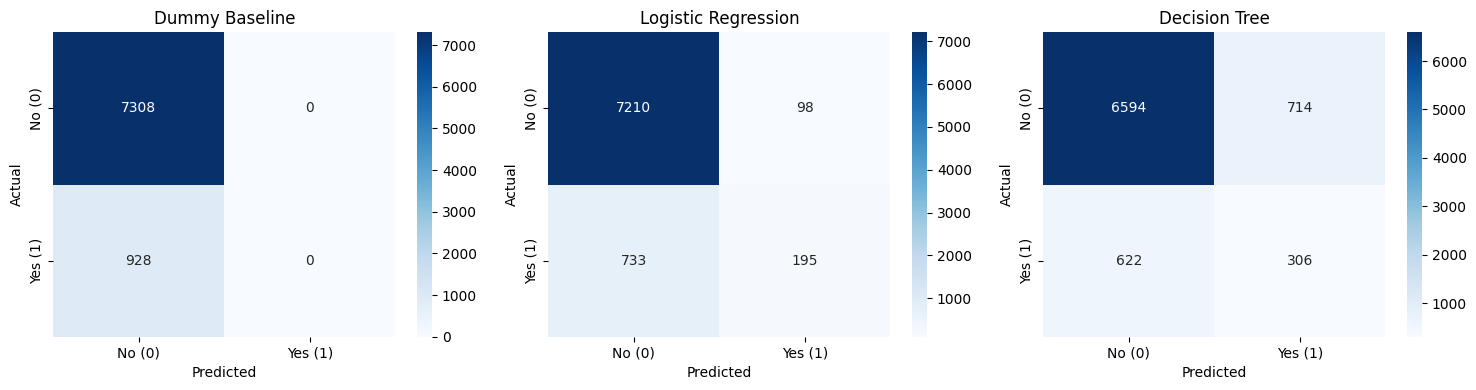

In [723]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

##### 4.2 Metrics Comparison

In [724]:
metrics_baseline = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    metrics_baseline.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Specificity':  round(tn / (tn + fp), 4),
        'F1 Score':     round(f1_score(y_test, y_pred, zero_division=0), 4),
    })

display(pd.DataFrame(metrics_baseline).set_index('Model'))

,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Dummy Baseline,0.8873,0.0000,0.0000,1.0000,0.0000
Logistic Regression,0.8991,0.6655,0.2101,0.9866,0.3194
Decision Tree,0.8378,0.3000,0.3297,0.9023,0.3142


### 5. Feature Engineering

Three new features are engineered to capture economic context that the existing features do not fully express individually. `df_fe` is created as a copy of the cleaned dataset so the original remains intact.

In [725]:
df_fe = df.copy()

##### 5.1 GDP Quarter-over-Quarter Growth (`gdp_qoq`)

**Formula:** percentage change in Portugal's quarterly GDP relative to the previous quarter

**External data:** `portugal-quarterly-gdp.csv` (quarterly GDP, seasonally adjusted)

Since the bank marketing data is chronologically sorted (May 2008 to November 2010) but contains no year column, years are inferred by detecting when the `month` value drops, indicating a year boundary. Quarter is then derived from month. These helper columns are dropped after merging with the GDP data.

**Why it matters:** A growing economy encourages saving and financial commitment, making clients more likely to subscribe to a term deposit. A contracting economy has the opposite effect, making clients hesitant to lock money away.

In [726]:
years = []
current_year = 2008
prev_month = None
for m in df_fe['month']:
    if prev_month is not None and m < prev_month:
        current_year += 1
    years.append(current_year)
    prev_month = m

df_fe['year'] = years
df_fe['quarter'] = ((df_fe['month'] - 1) // 3) + 1

gdp = pd.read_csv('data/raw/portugal-quarterly-gdp.csv')
gdp['observation_date'] = pd.to_datetime(gdp['observation_date'])
gdp['year'] = gdp['observation_date'].dt.year
gdp['quarter'] = gdp['observation_date'].dt.quarter
gdp = gdp.rename(columns={'CPMNACSCAB1GQPT': 'gdp'})
gdp['gdp_qoq'] = gdp['gdp'].pct_change() * 100
gdp = gdp[['year', 'quarter', 'gdp_qoq']]

df_fe = df_fe.merge(gdp, on=['year', 'quarter'], how='left')
df_fe = df_fe.drop(columns=['year', 'quarter'])

##### 5.2 Price-Adjusted Interest Index (`price_adjusted_interest`)

**Formula:** `euribor3m / cons.price.idx * 100`

**Why it matters:** A nominal interest rate alone does not tell the full story. A 4% rate is attractive when the cost of living is low, but far less compelling when prices are high. This feature combines both into a single measure of real interest attractiveness, capturing a distinction that either feature alone cannot express.

In [727]:
df_fe['price_adjusted_interest'] = df_fe['euribor3m'] / df_fe['cons.price.idx'] * 100

##### 5.3 Consumer Squeeze Index (`consumer_squeeze`)

**Formula:** `cons.price.idx * (-cons.conf.idx)`

**Why it matters:** When prices are high and consumer confidence is low, households are financially squeezed and far less likely to commit savings to a term deposit. Since `cons.conf.idx` is always negative in this dataset (less negative = more confident), negating it produces a positive pressure score. Multiplying by the price level amplifies the squeeze when both conditions are present simultaneously.

In [728]:
df_fe['consumer_squeeze'] = df_fe['cons.price.idx'] * (-df_fe['cons.conf.idx'])

##### 5.4 Train/Test Split (Feature Engineered Dataset)

Same 80/20 stratified split applied to `df_fe`. Exported as `train_engineered` and `test_engineered`.

In [729]:
X_fe = df_fe.drop(columns=['y'])
y_fe = df_fe['y']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe)

display(pd.DataFrame({
    'rows': [X_train_fe.shape[0], X_test_fe.shape[0]],
    '% of total': [round(X_train_fe.shape[0] / len(df_fe) * 100, 1), round(X_test_fe.shape[0] / len(df_fe) * 100, 1)]
}, index=['train', 'test']))

display(pd.DataFrame({
    'train count': [int((y_train_fe == v).sum()) for v in [0, 1]],
    'train %':     [round((y_train_fe == v).mean() * 100, 1) for v in [0, 1]],
    'test count':  [int((y_test_fe == v).sum()) for v in [0, 1]],
    'test %':      [round((y_test_fe == v).mean() * 100, 1) for v in [0, 1]],
}, index=['y=0 (no)', 'y=1 (yes)']))

train_eng = pd.concat([X_train_fe, y_train_fe], axis=1)
test_eng  = pd.concat([X_test_fe,  y_test_fe],  axis=1)

train_eng.to_csv('data/processed/train_engineered.csv', index=False)
test_eng.to_csv('data/processed/test_engineered.csv', index=False)
train_eng.to_parquet('data/processed/train_engineered.parquet', index=False)
test_eng.to_parquet('data/processed/test_engineered.parquet', index=False)

print(f"Exported (Train Engineered): {train_eng.shape[0]:,} rows x {train_eng.shape[1]} columns")
print(f"Exported (Test Engineered):  {test_eng.shape[0]:,} rows x {test_eng.shape[1]} columns")

,rows,% of total
train,32940,80.0
test,8236,20.0


,train count,train %,test count,test %
y=0 (no),29229,88.7,7308,88.7
y=1 (yes),3711,11.3,928,11.3


Exported (Train Engineered): 32,940 rows x 56 columns
Exported (Test Engineered):  8,236 rows x 56 columns


### 6. Modelling on Engineered Data

The same three models are retrained on the feature engineered dataset to assess whether the new features improve predictive performance.

In [730]:
models_fe = {
    'Dummy Baseline':      DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

for name, model in models_fe.items():
    model.fit(X_train_fe, y_train_fe)

##### 6.1 Confusion Matrices

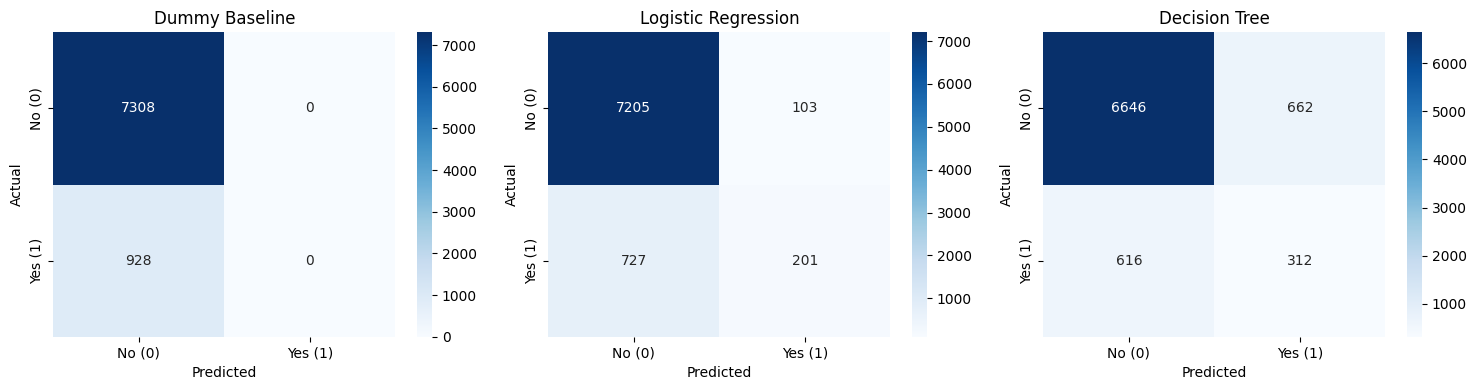

In [731]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models_fe.items()):
    cm = confusion_matrix(y_test_fe, model.predict(X_test_fe))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

##### 6.2 Metrics Comparison

In [732]:
metrics_fe = []
for name, model in models_fe.items():
    y_pred = model.predict(X_test_fe)
    tn, fp, fn, tp = confusion_matrix(y_test_fe, y_pred).ravel()
    metrics_fe.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test_fe, y_pred), 4),
        'Precision':    round(precision_score(y_test_fe, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test_fe, y_pred, zero_division=0), 4),
        'Specificity':  round(tn / (tn + fp), 4),
        'F1 Score':     round(f1_score(y_test_fe, y_pred, zero_division=0), 4),
    })

display(pd.DataFrame(metrics_fe).set_index('Model'))

,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Dummy Baseline,0.8873,0.0000,0.0000,1.0000,0.0000
Logistic Regression,0.8992,0.6612,0.2166,0.9859,0.3263
Decision Tree,0.8448,0.3203,0.3362,0.9094,0.3281


### 6. Evaluation

##### 6.1 Metrics Result Recap

In [733]:
base_df = pd.DataFrame(metrics_baseline).set_index('Model')
fe_df   = pd.DataFrame(metrics_fe).set_index('Model')
diff_df = (fe_df - base_df).round(4)

print("Baseline")
display(base_df)

print("Feature Engineered")
display(fe_df)

print("FE - Base")
display(diff_df)

Baseline


,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Dummy Baseline,0.8873,0.0000,0.0000,1.0000,0.0000
Logistic Regression,0.8991,0.6655,0.2101,0.9866,0.3194
Decision Tree,0.8378,0.3000,0.3297,0.9023,0.3142


Feature Engineered


,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Dummy Baseline,0.8873,0.0000,0.0000,1.0000,0.0000
Logistic Regression,0.8992,0.6612,0.2166,0.9859,0.3263
Decision Tree,0.8448,0.3203,0.3362,0.9094,0.3281


FE - Base


,Accuracy,Precision,Recall,Specificity,F1 Score
Model,,,,,
Dummy Baseline,0.0000,0.0000,0.0000,0.0000,0.0000
Logistic Regression,0.0001,-0.0043,0.0065,-0.0007,0.0069
Decision Tree,0.0070,0.0203,0.0065,0.0071,0.0139


##### 6.2 Observations

- The Dummy Baseline predicts the majority class (no subscription) for every sample. Its high accuracy (~88%) is misleading given the class imbalance. This confirms that accuracy alone is an insufficient metric for this problem.

- Since the goal is to identify clients likely to subscribe, missing a true positive (a client who would have subscribed) is more costly than a false alarm. This makes **recall the primary metric of interest**. A model that fails to flag potential subscribers means missed revenue opportunities for the bank. However, optimising for recall alone risks flooding the campaign with false positives, wasting resources on clients unlikely to convert. This makes F1 score an equally important metric, as it balances precision and recall. Hence, the consistently low recall and F1 scores across all models represent a critical problem. Possible reasons include:
    1) **Class imbalance:** with only ~12% positive cases, models are biased toward predicting "no" as the safe default
    2) **Default settings:** no threshold tuning, class weighting, or resampling applied
    3) **Model capacity:** Logistic Regression may underfit complex decision boundaries or the Decision Tree may overfit noise rather than learning generalised patterns

- The impact of feature engineering is modest at this stage. The three engineered features add macroeconomic context not directly captured by the original dataset, but the performance difference versus baseline, although positive, is still small. Possible reasons include:
    1) Models are at default settings with no tuning
    2) The original dataset already contains correlated macroeconomic indicators (`emp.var.rate`, `euribor3m`, `cons.price.idx`, `cons.conf.idx`)

### 7. References
[1] UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/222/bank+marketing

[2] Eurostat, "Real Gross Domestic Product for Portugal," FRED, Federal Reserve Bank of St. Louis, Jan. 01, 1995. https://fred.stlouisfed.org/series/CLVMNACSCAB1GQPT